# Разбор калибровки host-priority

Этот ноутбук показывает, насколько хорошо откалиброван сигнал `host_similarity_score` на holdout-части host-модели.

Что проверяем:
- базовые метрики качества `brier_score`, `log_loss`, `roc_auc`;
- кривую надежности и корзины вероятностей;
- поведение по группам `spec_class` и `evolution_stage`;
- хвосты score и зону неуверенности перед настройкой `priority`.


In [1]:
# Настройка: корень репозитория, `sys.path` и базовые визуальные параметры.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень репозитория из текущей рабочей директории.')

REPO_ROOT = find_repo_root(Path.cwd()).resolve()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Импортируем helper-модули обзора калибровки после добавления src в sys.path.
from exohost.reporting.binary_calibration_review import BinaryCalibrationConfig
from exohost.reporting.host_calibration_bundle import (
    find_latest_host_model_run_dir,
    load_host_calibration_review_bundle,
)
from exohost.reporting.notebook_display import rename_frame_for_display
from exohost.reporting.notebook_labels import (
    HOST_CALIBRATION_GROUP_LABELS,
    HOST_CALIBRATION_METRIC_LABELS,
)


## План

1. Найти актуальный артефакт host-модели.
2. Пересобрать reproducible holdout-source для calibration review.
3. Показать базовые метрики: `brier_score`, `log_loss`, `roc_auc`.
4. Посмотреть reliability curve и probability bins.
5. Проверить group-level behavior по `spec_class` и `evolution_stage`.
6. Посмотреть score-tails и uncertain zone перед решением о post-hoc calibration.

In [3]:
# Конфигурация ноутбук и разрешение актуального артефакта host-модели.
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts/models'
host_model_run_dir = find_latest_host_model_run_dir(ARTIFACTS_ROOT)
DOTENV_PATH = str(REPO_ROOT / '.env')
HOST_LIMIT: int | None = None
ROUTER_LIMIT: int | None = None
FIELD_TO_HOST_RATIO = 1
CALIBRATION_CONFIG = BinaryCalibrationConfig(positive_label='host', n_bins=10, strategy='quantile')

if host_model_run_dir is None or not host_model_run_dir.exists():
    raise FileNotFoundError('Не удалось определить артефакт host-модели для обзора калибровки.')

HOST_MODEL_RUN_DIR: Path = host_model_run_dir


In [4]:
# Загружаем host calibration bundle и основные review tables.
bundle = load_host_calibration_review_bundle(
    HOST_MODEL_RUN_DIR,
    host_limit=HOST_LIMIT,
    router_limit=ROUTER_LIMIT,
    field_to_host_ratio=FIELD_TO_HOST_RATIO,
    calibration_config=CALIBRATION_CONFIG,
    dotenv_path=DOTENV_PATH,
)

run_context_df = pd.DataFrame([
    {
        'model_run_dir': bundle.run_dir.name,
        'task_name': bundle.metadata.get('task_name', 'unknown'),
        'model_name': bundle.metadata.get('model_name', 'unknown'),
        'created_at_utc': bundle.metadata.get('created_at_utc', 'unknown'),
        'target_column': bundle.metadata.get('target_column', 'unknown'),
        'n_features': len(bundle.metadata.get('feature_columns', [])),
    }
])

display(
    rename_frame_for_display(
        run_context_df,
        column_mapping={
            'model_run_dir': 'Каталог артефакта модели',
            'task_name': 'Задача',
            'model_name': 'Модель',
            'created_at_utc': 'Время создания UTC',
            'target_column': 'Целевая колонка',
            'n_features': 'Число признаков',
        },
    )
)
display(
    rename_frame_for_display(
        bundle.split_summary_df,
        column_mapping={
            'task_name': 'Задача',
            'model_name': 'Модель',
            'n_rows_full': 'Число строк всего',
            'n_rows_train': 'Число строк train',
            'n_rows_test': 'Число строк test',
            'train_positive_rate': 'Доля host-класса в train',
            'test_positive_rate': 'Доля host-класса в test',
        },
    )
)
display(
    rename_frame_for_display(
        bundle.metric_summary_df,
        column_mapping={
            'n_rows': 'Число строк',
            'positive_rate': HOST_CALIBRATION_METRIC_LABELS['positive_rate'],
            'mean_predicted_probability': HOST_CALIBRATION_METRIC_LABELS['mean_predicted_probability'],
            'brier_score': HOST_CALIBRATION_METRIC_LABELS['brier_score'],
            'log_loss': HOST_CALIBRATION_METRIC_LABELS['log_loss'],
            'roc_auc': HOST_CALIBRATION_METRIC_LABELS['roc_auc'],
        },
    )
)


,Каталог артефакта модели,Задача,Модель,Время создания UTC,Целевая колонка,Число признаков
0,host_field_classification__hist_gradient_boost...,host_field_classification,hist_gradient_boosting,2026-03-29T07:16:01.090632+00:00,host_label,8


,Задача,Модель,Число строк всего,Число строк train,Число строк test,Доля host-класса в train,Доля host-класса в test
0,host_field_classification,hist_gradient_boosting,7406,5184,2222,0.5,0.5


,Число строк,Доля положительного класса,Средняя предсказанная вероятность,Brier score,Log loss,ROC AUC
0,2222,0.5,0.503894,0.035357,0.13408,0.990521


,Номер бина,Средняя предсказанная вероятность,Доля положительного класса
0,1,0.000006,0.000000
1,2,0.000013,0.000000
2,3,0.000040,0.000000
3,4,0.000293,0.004505
4,5,0.139357,0.225225
5,6,0.910010,0.824324
6,7,0.991568,0.972973
7,8,0.998129,0.972973
8,9,0.999614,1.000000
9,10,0.999945,1.000000


,Номер корзины,Интервал вероятности,Число строк,Доля,Доля host-класса,Средняя вероятность в корзине
0,Бин 1,0.0–0.1,1032,0.464446,0.012597,0.002514
1,Бин 2,0.1–0.2,18,0.008101,0.388889,0.141589
2,Бин 3,0.2–0.30000000000000004,16,0.007201,0.500000,0.240049
3,Бин 4,0.30000000000000004–0.4,11,0.004950,0.454545,0.337483
4,Бин 5,0.4–0.5,13,0.005851,0.461538,0.453244
5,Бин 6,0.5–0.6000000000000001,12,0.005401,0.500000,0.561511
6,Бин 7,0.6000000000000001–0.7000000000000001,17,0.007651,0.705882,0.653072
7,Бин 8,0.7000000000000001–0.8,23,0.010351,0.695652,0.754851
8,Бин 9,0.8–0.9,34,0.015302,0.705882,0.857930
9,Бин 10,0.9–1.0,1046,0.470747,0.969407,0.991102


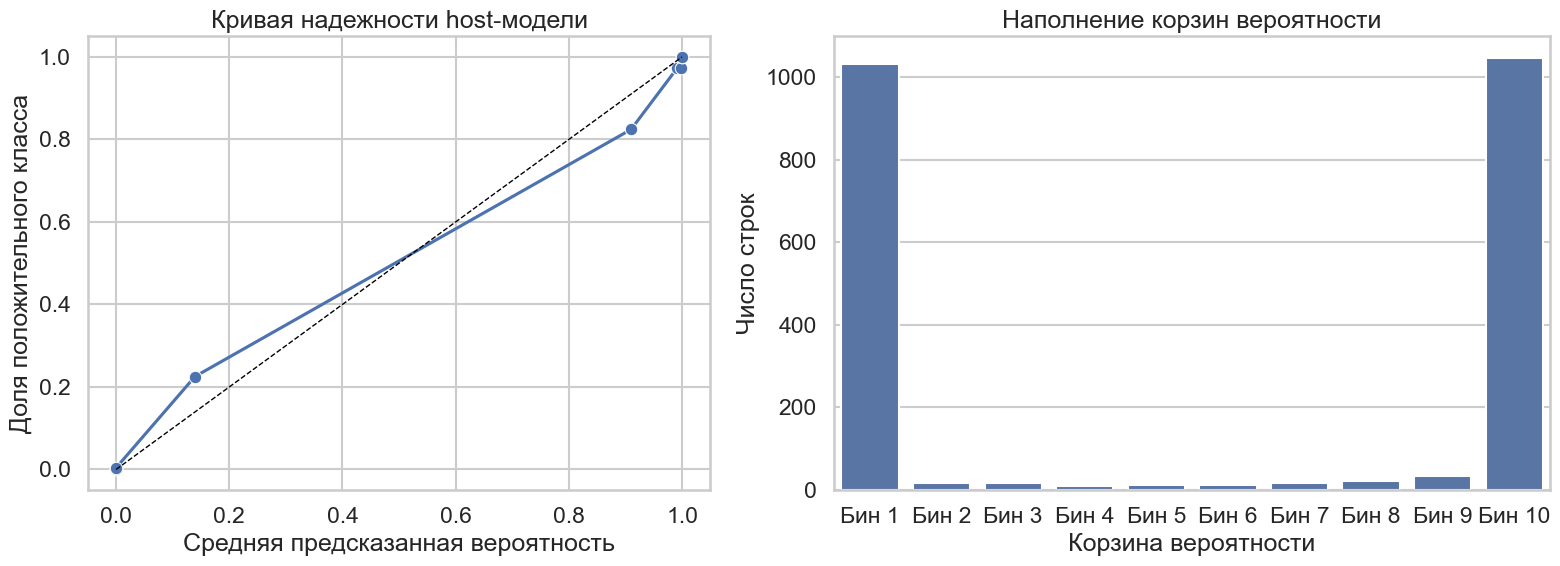

In [5]:
# Кривая надежности и наполнение корзин вероятности.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.15]})

curve_plot_df = bundle.curve_df.copy()
sns.lineplot(
    data=curve_plot_df,
    x='mean_predicted_probability',
    y='fraction_of_positives',
    marker='o',
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[0].set_title('Кривая надежности host-модели')
axes[0].set_xlabel('Средняя предсказанная вероятность')
axes[0].set_ylabel('Доля положительного класса')

bin_plot_df = bundle.probability_bin_df.copy()
bin_plot_df['bin_index'] = range(1, int(bin_plot_df.shape[0]) + 1)
bin_plot_df['bin_number'] = [f'Бин {index}' for index in bin_plot_df['bin_index']]
bin_plot_df['bin_interval'] = [
    str(value).replace('(', '').replace(')', '').replace('[', '').replace(']', '').replace(', ', '–')
    for value in bin_plot_df['probability_bin']
]

sns.barplot(data=bin_plot_df, x='bin_number', y='n_rows', ax=axes[1], color='#4C72B0')
axes[1].set_title('Наполнение корзин вероятности')
axes[1].set_xlabel('Корзина вероятности')
axes[1].set_ylabel('Число строк')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
display(
    rename_frame_for_display(
        bundle.curve_df,
        column_mapping={
            'bin_index': 'Номер бина',
            'mean_predicted_probability': 'Средняя предсказанная вероятность',
            'fraction_of_positives': 'Доля положительного класса',
        },
    )
)
display(
    rename_frame_for_display(
        bin_plot_df.loc[:, ['bin_number', 'bin_interval', 'n_rows', 'share', 'positive_rate', 'mean_probability']],
        column_mapping={
            'bin_number': 'Номер корзины',
            'bin_interval': 'Интервал вероятности',
            'n_rows': 'Число строк',
            'share': 'Доля',
            'positive_rate': 'Доля host-класса',
            'mean_probability': 'Средняя вероятность в корзине',
        },
    )
)


In [6]:
# Групповой обзор по spec_class и evolution_stage.
display(
    rename_frame_for_display(
        bundle.class_group_df,
        column_mapping={
            'spec_class': 'Спектральный класс',
            'n_rows': 'Число строк',
            'positive_rate': HOST_CALIBRATION_GROUP_LABELS['positive_rate'],
            'mean_host_similarity_score': HOST_CALIBRATION_GROUP_LABELS['mean_host_similarity_score'],
            'median_host_similarity_score': HOST_CALIBRATION_GROUP_LABELS['median_host_similarity_score'],
        },
    )
)
display(
    rename_frame_for_display(
        bundle.stage_group_df,
        column_mapping={
            'evolution_stage': 'Стадия эволюции',
            'n_rows': 'Число строк',
            'positive_rate': HOST_CALIBRATION_GROUP_LABELS['positive_rate'],
            'mean_host_similarity_score': HOST_CALIBRATION_GROUP_LABELS['mean_host_similarity_score'],
            'median_host_similarity_score': HOST_CALIBRATION_GROUP_LABELS['median_host_similarity_score'],
        },
    )
)


,Спектральный класс,Число строк,Доля host-класса,Средний host_similarity_score,Медианный host_similarity_score
0,G,1168,0.5,0.517021,0.758095
1,K,636,0.5,0.489497,0.220426
2,F,282,0.5,0.484313,0.285249
3,M,136,0.5,0.499089,0.489989


,Стадия эволюции,Число строк,Доля host-класса,Средний host_similarity_score,Медианный host_similarity_score
0,dwarf,2032,0.5,0.505497,0.686660
1,evolved,190,0.5,0.486747,0.417684


In [7]:
# Верхний хвост score и зона неуверенности на holdout-выборке.
preview_columns = [
    'source_id',
    'host_label',
    'predicted_host_label',
    'host_similarity_score',
    'spec_class',
    'evolution_stage',
    'teff_gspphot',
    'mh_gspphot',
    'parallax_over_error',
    'ruwe',
]
available_columns = [column for column in preview_columns if column in bundle.source.test_scored_df.columns]
test_scored_df = bundle.source.test_scored_df.loc[:, available_columns].copy()
test_scored_df['host_similarity_score'] = pd.to_numeric(test_scored_df['host_similarity_score'], errors='coerce')

top_host_like_df = test_scored_df.sort_values('host_similarity_score', ascending=False, kind='mergesort').head(15)
uncertain_df = (
    test_scored_df.assign(distance_to_half=(test_scored_df['host_similarity_score'] - 0.5).abs())
    .sort_values('distance_to_half', ascending=True, kind='mergesort')
    .head(15)
    .drop(columns=['distance_to_half'])
)

display(top_host_like_df)
display(uncertain_df)

,source_id,host_label,predicted_host_label,host_similarity_score,spec_class,evolution_stage,teff_gspphot,mh_gspphot,parallax_over_error,ruwe
1007,5876112300125320448,host,host,0.999991,G,dwarf,5797.2397,-0.1765,2060.01050,0.781616
716,1982946891164168576,host,host,0.999991,G,dwarf,5699.3150,-0.3201,1326.48560,1.051995
1021,3241295308714904960,host,host,0.999989,G,dwarf,5684.3040,-0.2026,1062.56040,0.908077
1367,5685917541714610688,host,host,0.999989,F,dwarf,6226.2000,-0.0409,693.41590,1.050879
33,3245123980001812864,host,host,0.999988,K,evolved,4775.0530,-0.2383,580.20825,1.008972
1648,1772187382746856320,host,host,0.999988,G,dwarf,5851.9370,-0.4305,1583.67140,1.160362
835,6018047019138644480,host,host,0.999988,G,dwarf,5723.8506,-0.3303,1173.21230,0.851425
2074,5945941905576552064,host,host,0.999987,G,dwarf,5590.9136,-0.0230,708.72360,0.857993
1447,5691782130578684544,host,host,0.999987,G,dwarf,5836.8735,-0.1808,1368.80220,1.083657
426,3538141457982396928,host,host,0.999987,G,dwarf,5623.2960,-0.0954,1096.31740,0.870546


,source_id,host_label,predicted_host_label,host_similarity_score,spec_class,evolution_stage,teff_gspphot,mh_gspphot,parallax_over_error,ruwe
1762,5003500972715494272,field,field,0.487400,G,evolved,5322.3780,-0.3707,59.968166,1.023040
1102,2052568585913107072,host,field,0.480923,F,dwarf,6017.8070,-0.3443,58.759563,0.995996
1153,2052144621107902208,host,field,0.477645,G,dwarf,5225.0825,-0.8345,25.208360,2.411523
1724,2101644600223555328,host,host,0.526117,K,evolved,5150.1304,-0.2071,38.480602,0.977300
2221,2078630756707737600,host,host,0.531355,G,dwarf,5379.7310,-0.8768,27.975441,1.022760
587,4285073581136130560,host,field,0.465819,K,dwarf,5072.0500,0.1682,26.325916,1.096489
151,3153787342928313856,field,field,0.464378,G,dwarf,5642.1274,-0.3397,28.401073,1.004197
921,360138028590504192,field,host,0.535726,F,dwarf,6357.2970,-0.3725,68.132450,1.037717
1584,2128469007448159232,host,host,0.538853,K,dwarf,4275.7866,0.1787,59.330940,0.942038
937,16727763746927872,field,field,0.458856,G,dwarf,5590.9900,-0.4955,143.179520,1.140803


## Как читать этот обзор

- если кривая надежности близка к диагонали, вероятности `host_similarity_score` согласованы с наблюдаемой частотой положительного класса;
- если столбцы распределения вероятностей сильно сжаты у краев, это сигнал к отдельной настройке порогов `priority`, а не обязательно к переобучению host-модели;
- групповые таблицы по `spec_class` и `evolution_stage` показывают, где калибровка выглядит устойчивой, а где нужен дополнительный разбор.
